In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
sf = sp.SingularityFunction

In [2]:
x, z = sp.symbols('x y')
EI, EA = sp.symbols('EI EA')
CV, CM, Cphi, Cuz, CN, Cux = sp.symbols('C_V C_M C_φ C_uz C_N C_ux') 

In [3]:
h_of_x = 1-sp.cos(x)
v_of_x = -sp.sin(x)

dh_dx = sp.diff(h_of_x,x)
d2h_dx2 = sp.diff(dh_dx,x)

dv_dx = sp.diff(v_of_x,x)
d2v_dx2 = sp.diff(dv_dx,x)

def h_x(x):
    return 1-np.cos(x)

def v_x(x):
    return -np.sin(x)

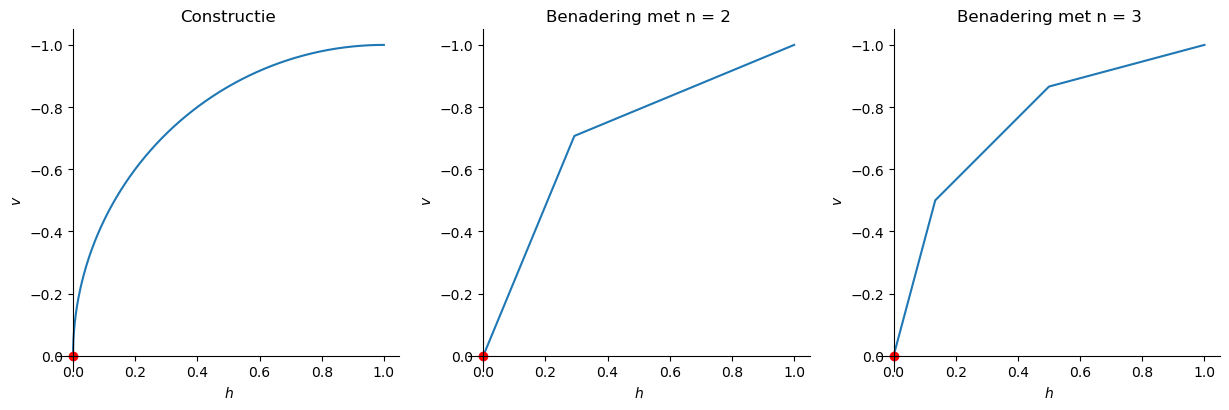

In [4]:
end = np.pi/2

Fh_h = 0
Fh_v = 0

n = [2, 3, 'r']
num = len(n)-1
h = np.zeros(len(n), dtype=object)
v = np.zeros(len(n), dtype=object)
x_np = np.zeros(len(n), dtype=object)
x_np[0] = np.linspace(0,end,1000)

fig, axes = plt.subplots(1, len(n), figsize=(15, 5))

for i in range(-1, num):
    if n[i] == 'r':
        x_np[i] = np.linspace(0,end,1000)
        titel = 'Constructie'
    else:
        x_np[i] = np.linspace(0,end,n[i]+1)
        titel = f'Benadering met n = {n[i]}'
    h[i] = np.zeros(len(x_np[i]))
    v[i] = np.zeros(len(x_np[i]))
    for j in range(len(x_np[i])):
        h[i][j] = h_x(x_np[i][j])
        v[i][j] = v_x(x_np[i][j])
    axes[i+1].plot(h[i], v[i])
    axes[i+1].plot(Fh_h,Fh_v, marker='o', label= 'Fh', color= 'r')
    axes[i+1].set_xlabel('$h$')
    axes[i+1].set_ylabel('$v$')
    axes[i+1].set_title(titel)
    axes[i+1].spines['right'].set_color('none')
    axes[i+1].spines['top'].set_color('none')
    axes[i+1].spines['bottom'].set_position('zero')
    axes[i+1].spines['left'].set_position('zero')
    axes[i+1].invert_yaxis()
    axes[i+1].set_aspect('equal')

In [5]:
a = np.zeros(num, dtype=object)
theta = np.zeros(num, dtype=object)
b = np.zeros(len(n), dtype=object)
thetab = np.zeros(num, dtype=object)

for i in range(num):
    a[i] = np.zeros(len(h[i]))
    theta[i] = np.zeros(len(h[i])-1)
    b[i] = np.zeros(2)
    for j in range(1,len(a[i])):
        a[i][j] = a[i][j-1] + np.sqrt((h[i][j]-h[i][j-1])**2 + (v[i][j]-v[i][j-1])**2)
    for j in range(0,len(theta[i])):
        theta[i][j] = np.arctan(-(v[i][j+1]-v[i][j])/(h[i][j+1]-h[i][j]))
    for j in range(len(a[i])):
        if h[i][j]==Fh_h:
            b[i][0] = a[i][j]
            thetab[i] = theta[i][j]
    b[i][1] = a[i][-1]

b[-1] = [0, end]

In [6]:
def qz_Fv(Fv, b):
    return Fv * (sf(x,b,-1)*dh_dx.subs(x,b) + d2h_dx2*sf(x,b,0))

def qx_Fv(Fv, b):
    return Fv * (sf(x,b,-1)*dv_dx.subs(x,b) + d2v_dx2*sf(x,b,0))

def qz_Fh(Fh, b):
    return -Fh * (sf(x,b,-1)*dv_dx.subs(x,b) + d2v_dx2*sf(x,b,0))

def qx_Fh(Fh, b):
    return Fh * (sf(x,b,-1)*dh_dx.subs(x,b) + d2h_dx2*sf(x,b,0))

def qz_T(T, b):
    return T * sf(x,b,-2)

In [7]:
Fh, Rv, Rh, Tr = sp.symbols('Fh R_v R_h T_R')

qz = np.zeros(len(n), dtype=object)
qx = np.zeros(len(n), dtype=object)

for i in range(num):
    qz[i] = (Fh * sf(x,b[i][0],-1) * np.sin(thetab[i]) + 
             Rv * sf(x,b[i][1],-1) * np.cos(theta[i][-1]) + 
             Rh * sf(x,b[i][1],-1) * np.sin(theta[i][-1]) +
             Tr * sf(x,b[i][1],-2))

    for j in range(len(theta[i])):
        if a[i][j] > b[i][0]:
            qz[i] += Fh * sf(x,a[i][j],-1) * (np.sin(theta[i][j]) - np.sin(theta[i][j-1]))

    qx[i] = (Fh * sf(x,b[i][0],-1) * np.cos(thetab[i]) - 
             Rv * sf(x,b[i][1],-1) * np.sin(theta[i][-1]) + 
             Rh * sf(x,b[i][1],-1) * np.cos(theta[i][-1]))

    for j in range(len(theta[i])):
        if a[i][j] > b[i][0]:
            qx[i] += Fh * sf(x,a[i][j],-1) * (np.cos(theta[i][j]) - np.cos(theta[i][j-1]))

qz[-1] = qz_Fh(Fh, b[-1][0]) + qz_Fv(Rv, b[-1][1]) + qz_Fh(Rh, b[-1][1]) + qz_T(Tr, b[-1][1])
qx[-1] = qx_Fh(Fh, b[-1][0]) + qx_Fv(Rv, b[-1][1]) + qx_Fh(Rh, b[-1][1])

In [8]:
V = np.zeros(len(n), dtype=object)
M = np.zeros(len(n), dtype=object)
kappa = np.zeros(len(n), dtype=object)
phi = np.zeros(len(n), dtype=object)
uz = np.zeros(len(n), dtype=object)
N = np.zeros(len(n), dtype=object)
epsilon = np.zeros(len(n), dtype=object)
ux = np.zeros(len(n), dtype=object)

for i in range(len(n)):
    V[i] = -sp.integrate(qz[i], x) + CV
    M[i] = sp.integrate(V[i], x) + CM
    kappa[i] = M[i] / EI
    phi[i] = sp.integrate(kappa[i], x) + Cphi
    uz[i] = -sp.integrate(phi[i], x) + Cuz

    N[i] = -sp.integrate(qx[i], x) + CN
    epsilon[i] = N[i] / EA
    ux[i] = sp.integrate(epsilon[i], x) + Cux

In [9]:
uvz = np.zeros(len(n), dtype=object)
uvx = np.zeros(len(n), dtype=object)
uhz = np.zeros(len(n), dtype=object)
uhx = np.zeros(len(n), dtype=object)
uv = np.zeros(len(n), dtype=object)
uh = np.zeros(len(n), dtype=object)

for i in range(num):
    uvz[i] = uz[i].subs(x,a[i][0]) * sp.cos(theta[i][0])
    uvx[i] = -ux[i].subs(x,a[i][0]) * sp.sin(theta[i][0])
    for j in range(len(theta[i])):
        uvz[i] += ((uz[i] - uz[i].subs(x,a[i][j])) * sf(x,a[i][j],0) - (uz[i] - uz[i].subs(x,a[i][j+1])) * sf(x,a[i][j+1],0)) * sp.cos(theta[i][j])
        uvx[i] += -((ux[i] - ux[i].subs(x,a[i][j])) * sf(x,a[i][j],0) - (ux[i] - ux[i].subs(x,a[i][j+1])) * sf(x,a[i][j+1],0)) * sp.sin(theta[i][j])
    uv[i] = uvz[i] + uvx[i]

    uhz[i] = uz[i].subs(x,a[i][0]) * sp.sin(theta[i][0])
    uhx[i] = ux[i].subs(x,a[i][0]) * sp.cos(theta[i][0])
    for j in range(len(theta[i])):
        uhz[i] += ((uz[i] - uz[i].subs(x,a[i][j])) * sf(x,a[i][j],0) - (uz[i] - uz[i].subs(x,a[i][j+1])) * sf(x,a[i][j+1],0)) * sp.sin(theta[i][j])
        uhx[i] += ((ux[i] - ux[i].subs(x,a[i][j])) * sf(x,a[i][j],0) - (ux[i] - ux[i].subs(x,a[i][j+1])) * sf(x,a[i][j+1],0)) * sp.cos(theta[i][j])
    uh[i] = uhz[i] + uhx[i]

s = sp.symbols('s')

uvz[-1] = uz[-1] * dh_dx - sp.integrate(uz[-1].subs(x,s) * d2h_dx2.subs(x,s), (s, 0, x))
uvx[-1] = ux[-1] * dv_dx - sp.integrate(ux[-1].subs(x,s) * d2v_dx2.subs(x,s), (s, 0, x))
uhz[-1] = -uz[-1] * dv_dx + sp.integrate(uz[-1].subs(x,s) * d2v_dx2.subs(x,s), (s, 0, x))
uhx[-1] = ux[-1] * dh_dx - sp.integrate(ux[-1].subs(x,s) * d2h_dx2.subs(x,s), (s, 0, x))

uv[-1] = uvz[-1] + uvx[-1]
uh[-1] = uhz[-1] + uhx[-1]

In [10]:
oo = sp.Dummy('oo', prime=True)
dx = 1/oo

Eq1 = [sp.Eq(N[i].subs(x,b[i][0]-dx),0).subs(oo,sp.oo) for i in range(len(n))]
Eq2 = [sp.Eq(N[i].subs(x,b[i][1]+dx),0).subs(oo,sp.oo) for i in range(len(n))]
Eq3 = [sp.Eq(V[i].subs(x,b[i][0]-dx),0).subs(oo,sp.oo) for i in range(len(n))]
Eq4 = [sp.Eq(V[i].subs(x,b[i][1]+dx),0).subs(oo,sp.oo) for i in range(len(n))]
Eq5 = [sp.Eq(M[i].subs(x,b[i][0]),0) for i in range(len(n))]
Eq6 = [sp.Eq(M[i].subs(x,b[i][1]+dx),0).subs(oo,sp.oo) for i in range(len(n))]
Eq7 = [sp.Eq(phi[i].subs(x,b[i][1]),0) for i in range(len(n))]
Eq8 = [sp.Eq(uv[i].subs(x,b[i][1]),0) for i in range(len(n))]
Eq9 = [sp.Eq(uh[i].subs(x,b[i][1]),0) for i in range(len(n))]

In [11]:
sol = [sp.solve((Eq1[i],Eq2[i],Eq3[i],Eq4[i],Eq5[i],Eq6[i],Eq7[i],Eq8[i],Eq9[i]),(Rv,Rh,Tr,CN,CV,CM,Cphi,Cuz,Cux)) for i in range(len(n))]
factors = {Fh: 5000, 
           EI: 3 * 10**4, 
           EA: 10**4}

In [12]:
display(f'{Rv} = {Rv.subs(sol[0]).subs(factors)}')
display(f'{Rh} = {Rh.subs(sol[0]).subs(factors)}')
display(f'{Tr} = {Tr.subs(sol[0]).subs(factors)}')

display(f'{CN} = {CN.subs(sol[0]).subs(factors)}')
display(f'{CV} = {CV.subs(sol[0]).subs(factors)}')
display(f'{CM} = {CM.subs(sol[0]).subs(factors)}')
display(f'{Cphi} = {Cphi.subs(sol[0]).subs(factors)}')
display(f'{Cux} = {Cux.subs(sol[0]).subs(factors)}')
display(f'{Cuz} = {Cuz.subs(sol[0]).subs(factors)}')

'R_v = 0.0'

'R_h = -5000'

'T_R = -5000'

'C_N = 0.0'

'C_V = 0.0'

'C_M = 0.0'

'C_φ = 0.153979922085215'

'C_ux = 0.365298822085625'

'C_uz = 0.387492985230718'

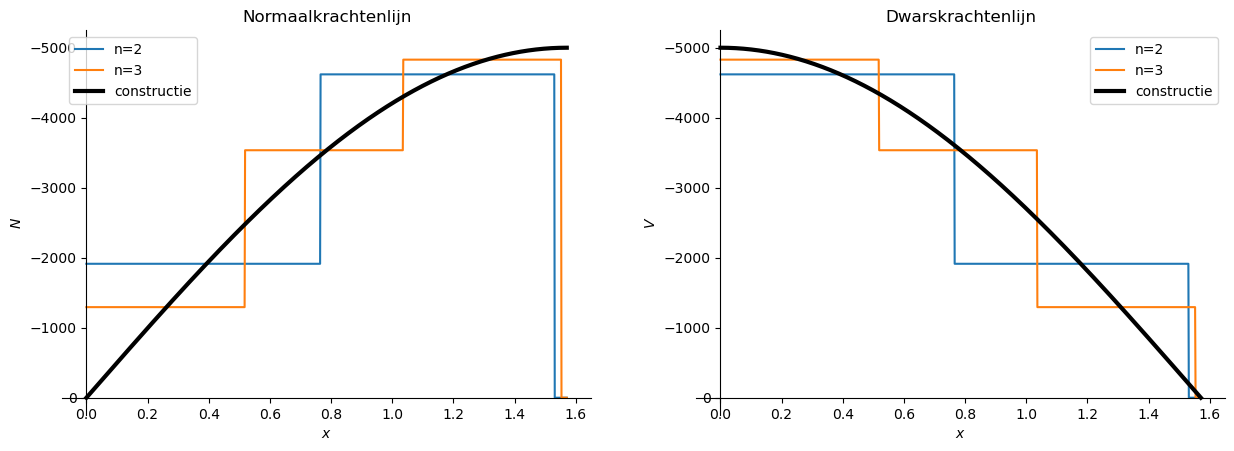

In [13]:
N_np = [sp.lambdify(x, N[i].subs(sol[i]).subs(factors).rewrite(sp.Piecewise)) for i in range(len(n))]
V_np = [sp.lambdify(x, V[i].subs(sol[i]).subs(factors).rewrite(sp.Piecewise)) for i in range(len(n))]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i in range(len(n)):
    if n[i] == 'r':
        axes[0].plot(x_np[-1],N_np[i](x_np[-1]), label='constructie', color='black', linewidth=3)
        axes[1].plot(x_np[-1],V_np[i](x_np[-1]), label='constructie', color='black', linewidth=3)
    else:
        axes[0].plot(x_np[-1],N_np[i](x_np[-1]), label = f'n={n[i]}')
        axes[1].plot(x_np[-1],V_np[i](x_np[-1]), label = f'n={n[i]}')
    axes[0].legend()
    axes[0].set_xlabel('$x$')
    axes[0].set_ylabel('$N$')
    axes[0].set_title('Normaalkrachtenlijn')
    axes[0].spines['right'].set_color('none')
    axes[0].spines['top'].set_color('none')
    axes[0].spines['bottom'].set_position('zero')
    axes[0].spines['left'].set_position('zero')

    axes[1].legend()
    axes[1].set_xlabel('$x$')
    axes[1].set_ylabel('$V$')
    axes[1].set_title('Dwarskrachtenlijn')
    axes[1].spines['right'].set_color('none')
    axes[1].spines['top'].set_color('none')
    axes[1].spines['bottom'].set_position('zero')
    axes[1].spines['left'].set_position('zero')

axes[0].invert_yaxis()
axes[1].invert_yaxis()

In [14]:
v_co = np.zeros(num, dtype=object)
h_co = np.zeros(num, dtype=object)
v_np = np.zeros(len(n), dtype=object)
h_np = np.zeros(len(n), dtype=object)
for i in range(num):
    for j in range(len(theta[i])):
        v_co[i] += -(sf(x,a[i][j],1) - sf(x,a[i][j+1],1)) * sp.sin(theta[i][j])
        h_co[i] += (sf(x,a[i][j],1) - sf(x,a[i][j+1],1)) * sp.cos(theta[i][j])
    v_np[i] = sp.lambdify(x, v_co[i].rewrite(sp.Piecewise))
    h_np[i] = sp.lambdify(x, h_co[i].rewrite(sp.Piecewise))
v_np[-1] = sp.lambdify(x, v_of_x.rewrite(sp.Piecewise))
h_np[-1] = sp.lambdify(x, h_of_x.rewrite(sp.Piecewise))
print(v_co[0])

-0.923879532511287*SingularityFunction(x, 0.0, 1) + 0.541196100146197*SingularityFunction(x, 0.76536686473018, 1) + 0.38268343236509*SingularityFunction(x, 1.53073372946036, 1)


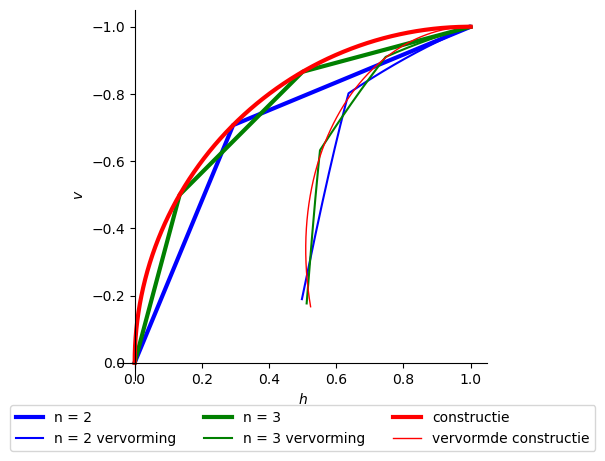

In [16]:
uv_np = [sp.lambdify(x, uv[i].subs(sol[i]).subs(factors).rewrite(sp.Piecewise)) for i in range(len(n))]
uh_np = [sp.lambdify(x, uh[i].subs(sol[i]).subs(factors).rewrite(sp.Piecewise)) for i in range(len(n))]

plt.figure()
colors = ['blue', 'green']
for i in range(num):
    c = colors[i]
    line = plt.plot(h_np[i](x_np[-1]),v_np[i](x_np[-1]), linewidth=3, color=c, label=f'n = {n[i]}')
    plt.plot(h_np[i](x_np[-1])+uh_np[i](x_np[-1]),v_np[i](x_np[-1])+uv_np[i](x_np[-1]), label=f'n = {n[i]} vervorming', color=c)
plt.plot(h_np[-1](x_np[-1]),v_np[-1](x_np[-1]), linewidth=3, color='r', label='constructie')
plt.plot((h_np[-1](x_np[-1])+uh_np[-1](x_np[-1])),(v_np[-1](x_np[-1])+uv_np[-1](x_np[-1])), linewidth=1, color='r', label='vervormde constructie')
plt.xlabel('$h$')
plt.ylabel('$v$');
ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
plt.axis('scaled')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),fancybox=True, shadow=False, ncol=3);
ax.invert_yaxis()